In [2]:
print("My Data Analytics Project Started")

My Data Analytics Project Started


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_excel('../data/online_retail_II.xlsx')

# Display first 5 rows
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [2]:
# Shape of dataset
print("Dataset Shape:")
print(df.shape)

# Column names
print("\nColumn Names:")
print(df.columns)

# Data types
print("\nData Types:")
print(df.dtypes)

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape:
(525461, 8)

Column Names:
Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

Data Types:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

Missing Values:
Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64


In [3]:
# Remove missing values
df = df.dropna()

# Remove duplicate rows
df = df.drop_duplicates()

# Create TotalPrice column
df['TotalPrice'] = df['Quantity'] * df['Price']

# Display first 5 rows
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [4]:
print("Cleaned Dataset Shape:")
print(df.shape)

Cleaned Dataset Shape:
(410763, 9)


In [5]:
# Total Revenue
total_revenue = df['TotalPrice'].sum()

print("Total Revenue:")
print(total_revenue)

# Average Order Value
average_order = df['TotalPrice'].mean()

print("\nAverage Order Value:")
print(average_order)

# Unique Customers
unique_customers = df['Customer ID'].nunique()

print("\nUnique Customers:")
print(unique_customers)

# Top 10 Countries by Revenue
top_countries = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

print("\nTop 10 Countries by Revenue:")
print(top_countries)

Total Revenue:
8314855.583999998

Average Order Value:
20.242464837387978

Unique Customers:
4383

Top 10 Countries by Revenue:
Country
United Kingdom    7005793.443
EIRE               328234.260
Netherlands        263861.760
Germany            195920.421
France             129665.480
Sweden              50836.110
Denmark             46972.950
Switzerland         43343.410
Spain               37052.130
Australia           30051.800
Name: TotalPrice, dtype: float64


In [6]:
# Create YearMonth column
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

# Monthly Revenue
monthly_revenue = df.groupby('YearMonth')['TotalPrice'].sum()

# Display monthly revenue
print(monthly_revenue.head())

YearMonth
2009-12    660125.100
2010-01    530436.512
2010-02    487596.426
2010-03    633419.311
2010-04    558007.832
Freq: M, Name: TotalPrice, dtype: float64


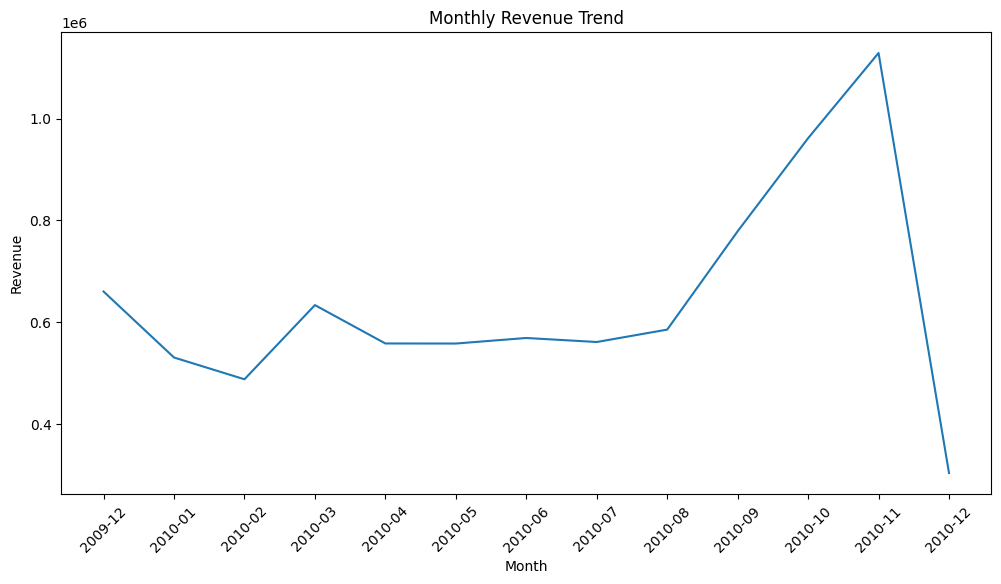

In [7]:
# Convert index to string for plotting
monthly_revenue.index = monthly_revenue.index.astype(str)

# Plot monthly revenue trend
plt.figure(figsize=(12,6))

plt.plot(monthly_revenue.index, monthly_revenue.values)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.xticks(rotation=45)

plt.show()

In [8]:
# Top 10 selling products
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

# Display top products
print(top_products)

Description
WHITE HANGING HEART T-LIGHT HOLDER    55760
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54130
BROCADE RING PURSE                    47430
PACK OF 72 RETRO SPOT CAKE CASES      44480
ASSORTED COLOUR BIRD ORNAMENT         44000
60 TEATIME FAIRY CAKE CASES           35480
PACK OF 60 PINK PAISLEY CAKE CASES    30753
JUMBO BAG RED RETROSPOT               29439
BLACK AND WHITE PAISLEY FLOWER MUG    25679
SMALL POPCORN HOLDER                  25379
Name: Quantity, dtype: int64


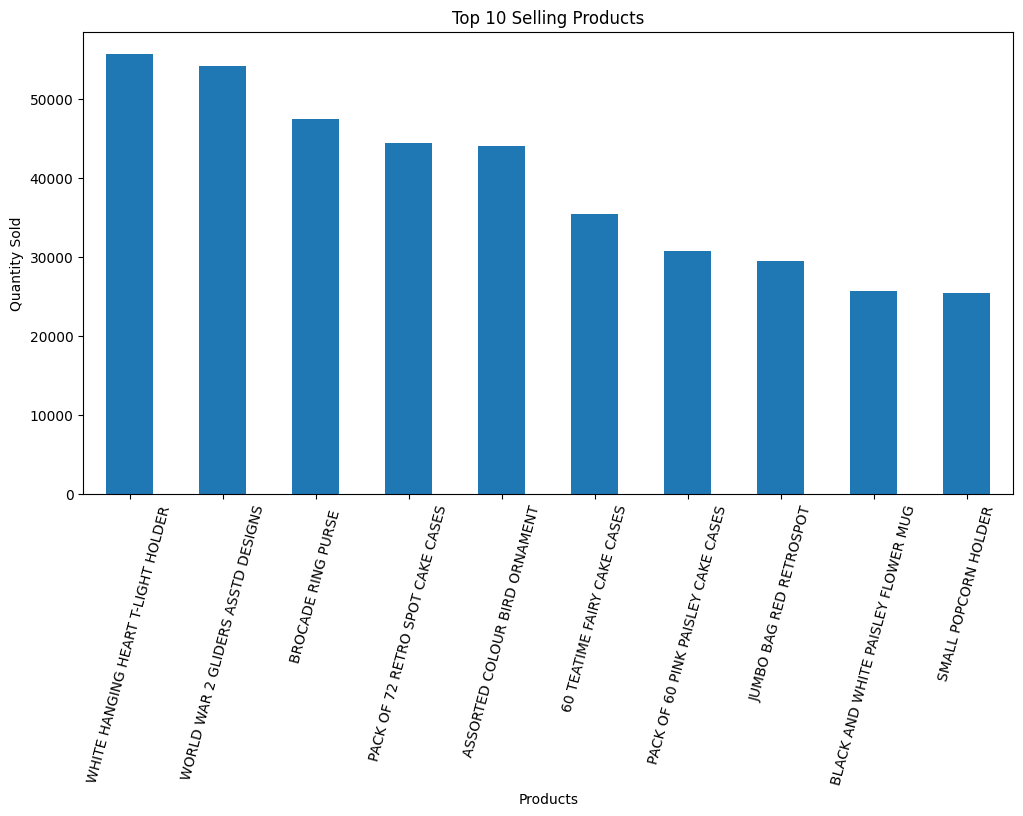

In [9]:
# Plot top selling products

plt.figure(figsize=(12,6))

top_products.plot(kind='bar')

plt.title('Top 10 Selling Products')
plt.xlabel('Products')
plt.ylabel('Quantity Sold')

plt.xticks(rotation=75)

plt.show()

In [10]:
# Top 10 customers by spending
top_customers = df.groupby('Customer ID')['TotalPrice'].sum().sort_values(ascending=False).head(10)

# Display top customers
print(top_customers)

Customer ID
18102.0    341776.73
14646.0    243853.05
14156.0    183163.55
14911.0    137710.76
13694.0    128172.42
17511.0     83760.60
15061.0     82162.74
16684.0     75610.17
13089.0     55801.73
16754.0     54558.18
Name: TotalPrice, dtype: float64


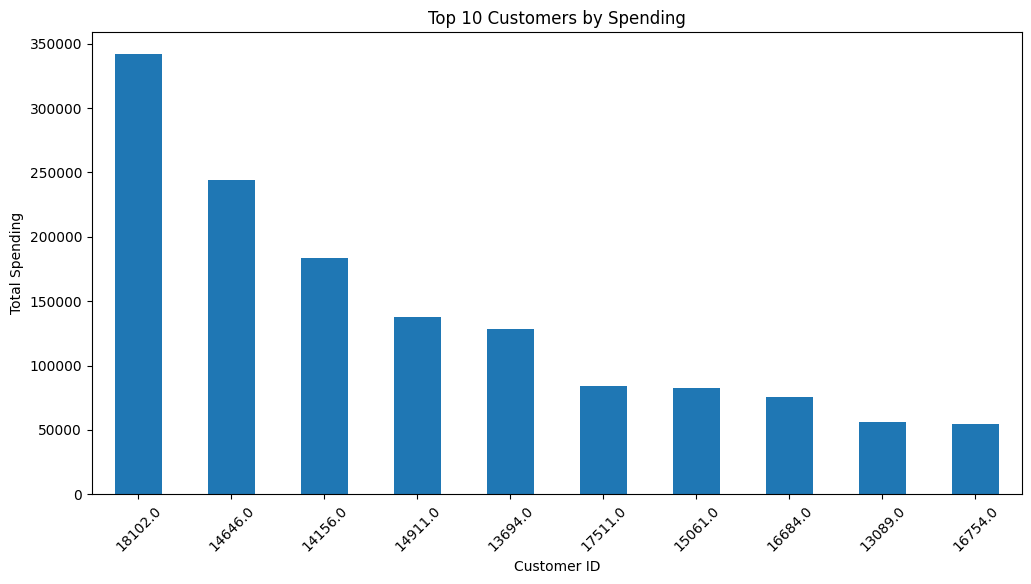

In [11]:
# Plot top customers

plt.figure(figsize=(12,6))

top_customers.plot(kind='bar')

plt.title('Top 10 Customers by Spending')
plt.xlabel('Customer ID')
plt.ylabel('Total Spending')

plt.xticks(rotation=45)

plt.show()

In [12]:
# Create reference date
reference_date = df['InvoiceDate'].max()

print(reference_date)

2010-12-09 20:01:00


In [13]:
# Create RFM table

rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'Invoice': 'count',
    'TotalPrice': 'sum'
})

# Rename columns
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# Display first rows
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,66,45,-51.74
12347.0,2,71,1323.32
12348.0,73,20,222.16
12349.0,42,107,2646.99
12351.0,10,21,300.93


In [14]:
# Create customer segments

rfm['CustomerSegment'] = 'Low Value'

rfm.loc[
    (rfm['Monetary'] > rfm['Monetary'].quantile(0.75)),
    'CustomerSegment'
] = 'High Value'

rfm.loc[
    (
        (rfm['Monetary'] > rfm['Monetary'].quantile(0.40)) &
        (rfm['Monetary'] <= rfm['Monetary'].quantile(0.75))
    ),
    'CustomerSegment'
] = 'Medium Value'

# Display first rows
rfm.head()

,Recency,Frequency,Monetary,CustomerSegment
Customer ID,,,,
12346.0,66,45,-51.74,Low Value
12347.0,2,71,1323.32,Medium Value
12348.0,73,20,222.16,Low Value
12349.0,42,107,2646.99,High Value
12351.0,10,21,300.93,Low Value


In [15]:
# Count customer segments

segment_counts = rfm['CustomerSegment'].value_counts()

print(segment_counts)

CustomerSegment
Low Value       1753
Medium Value    1534
High Value      1096
Name: count, dtype: int64


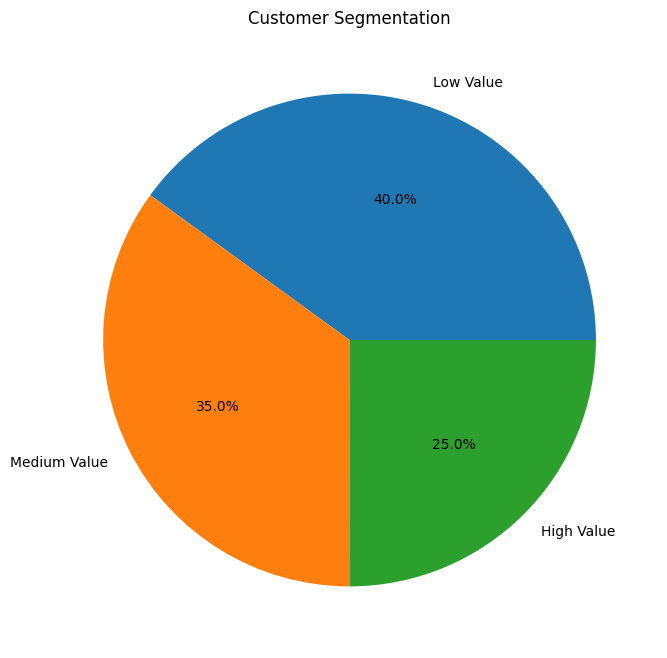

In [16]:
# Plot customer segments

plt.figure(figsize=(8,8))

segment_counts.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Customer Segmentation')

plt.ylabel('')

plt.show()

In [17]:
# Export cleaned dataset

df.to_csv('../dashboard/cleaned_ecommerce_data.csv', index=False)

print("Cleaned dataset exported successfully")

Cleaned dataset exported successfully
